In [320]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random
import pickle
import compress_fasttext

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [321]:
SOS_token = 0
EOS_token = 1
translations_file = 'from_transcripts.pkl'
embedder = compress_fasttext.models.CompressedFastTextKeyedVectors.load('cc.de.100.reduced.bin')
embedding_dim = 100

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "SOS", 1: "EOS"}
        self.n_words = 2  # Count SOS and EOS

    def addSentence(self, sentence):
        for word in sentence:
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

In [322]:
# Turn a Unicode string to plain ASCII, thanks to
# https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

# Lowercase, trim, and remove non-letter characters
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z!?]+", r" ", s)
    return s.strip()

In [323]:
import torchtext; torchtext.disable_torchtext_deprecation_warning()
from torchtext.data import get_tokenizer

def tokenize(sentence):
    tok = get_tokenizer("moses", language='de')
    #tokens = []
    #for token in tok(sentence):
    #    if token not in [".", ",", ":", "'", "!", ";", "/", "\\", "-", "(", ")"]:
    #        tokens.append(token)
    return tok(sentence)


def clean_token(token):
    if not re.search(r'[a-zA-Z]', token):
        token = ' '

    pattern = re.compile(r':(\d+)[\w\*]*')
    to_remove = ["$GEST-NM-", "$GEST-", "$NUM-", "$EXTRA-LING-"]
    number = ''

    if "$NUM" in token or "$INDEX" in token:
        match = pattern.search(token)
        if match:
            number = match.group(1)

    for substring in to_remove:
        token = token.replace(substring, '')

    token = token.lower()
    token = re.sub(r'\d.*', '', token)
    token = re.sub(r'[/^*|:$]', '', token)
    token = re.sub(r'-', ' ', token)
    token = token + number

    return token

def readLangs(file, reverse=False):
    print("Reading data...")

    # Read the file and split into lines
    with open(file, 'rb') as f:
        data = pickle.load(f)

    # Split every line into pairs and normalize
    pairs = [[tokenize(de), [clean_token(token) for token in dgs]] for de, dgs in zip(data['de'], data['dgs'])]

    # Reverse pairs, make Lang instances
    if not reverse:
        pairs = [list(reversed(p)) for p in pairs]
        input_lang = Lang('de')
        output_lang = Lang('dgs')
    else:
        input_lang = Lang('dgs')
        output_lang = Lang('de')

    return input_lang, output_lang, pairs

In [324]:
MAX_LENGTH = 10

def filterPair(p):
    return len(p[0]) < MAX_LENGTH and len(p[1]) < MAX_LENGTH


def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

In [325]:
def prepareData(file, reverse=False):
    input_lang, output_lang, pairs = readLangs(file, reverse)
    print("Read %s sentence pairs" % len(pairs))
    pairs = filterPairs(pairs)
    print("Trimmed to %s sentence pairs" % len(pairs))
    print("Counting words...")
    for pair in pairs:
        input_lang.addSentence(pair[0])
        output_lang.addSentence(pair[1])
    print("Counted words:")
    print(input_lang.name, input_lang.n_words)
    print(output_lang.name, output_lang.n_words)
    return input_lang, output_lang, pairs

# input_lang, output_lang, pairs = prepareData(translations_file, True)
# print(random.choice(pairs))

In [326]:
class EncoderRNN(nn.Module):
    def __init__(self, input_size, hidden_size, dropout_p=0.1):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, input):
        #embedded = self.dropout(self.embedding(input))
        output, hidden = self.gru(input)
        return output, hidden

In [327]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super(BahdanauAttention, self).__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, query, keys):
        scores = self.Va(torch.tanh(self.Wa(query) + self.Ua(keys)))
        scores = scores.squeeze(2).unsqueeze(1)

        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights, keys)

        return context, weights

class AttnDecoderRNN(nn.Module):
    def __init__(self, hidden_size, output_size, dropout_p=0.1):
        super(AttnDecoderRNN, self).__init__()
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(2 * hidden_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, encoder_outputs, encoder_hidden, target_tensor=None):
        batch_size = encoder_outputs.size(0)
        decoder_input = torch.empty(batch_size, 1, dtype=torch.long, device=device).fill_(SOS_token)
        decoder_hidden = encoder_hidden
        decoder_outputs = []
        attentions = []

        for i in range(MAX_LENGTH):
            decoder_output, decoder_hidden, attn_weights = self.forward_step(
                decoder_input, decoder_hidden, encoder_outputs
            )
            decoder_outputs.append(decoder_output)
            attentions.append(attn_weights)

            if target_tensor is not None:
                # Teacher forcing: Feed the target as the next input
                decoder_input = target_tensor[:, i].unsqueeze(1) # Teacher forcing
            else:
                # Without teacher forcing: use its own predictions as the next input
                _, topi = decoder_output.topk(1)
                decoder_input = topi.squeeze(-1).detach()  # detach from history as input

        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        decoder_outputs = F.log_softmax(decoder_outputs, dim=-1)
        attentions = torch.cat(attentions, dim=1)

        return decoder_outputs, decoder_hidden, attentions


    def forward_step(self, input, hidden, encoder_outputs):
        embedded =  self.dropout(self.embedding(input))

        query = hidden.permute(1, 0, 2)
        context, attn_weights = self.attention(query, encoder_outputs)
        input_gru = torch.cat((embedded, context), dim=2)

        output, hidden = self.gru(input_gru, hidden)
        output = self.out(output)

        return output, hidden, attn_weights

In [328]:
def indexesFromSentence(lang, sentence):
    return [lang.word2index[word] for word in sentence]

def tensorFromSentence(lang, sentence):
    indexes = indexesFromSentence(lang, sentence)
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(1, -1)

def tensorsFromPair(pair):
    input_tensor = tensorFromSentence(input_lang, pair[0])
    target_tensor = tensorFromSentence(output_lang, pair[1])
    return (input_tensor, target_tensor)

def sentence2vec(tokens):
    # print("[sentence2vec]", tokens)
    embeddings = [torch.tensor(embedder[token], device=device) for token in tokens]
    return torch.stack(embeddings).squeeze().to(device)

def get_dataloader(batch_size):
    input_lang, output_lang, pairs = prepareData(translations_file, True)

    n = len(pairs)
    input_vecs = torch.zeros((n, MAX_LENGTH, embedding_dim))
    target_ids = np.zeros((n, MAX_LENGTH), dtype=np.int32)

    for idx, (inp, tgt) in enumerate(pairs):
        tgt_ids = indexesFromSentence(output_lang, tgt)
        tgt_ids.append(EOS_token)
        inp_vec = sentence2vec(inp)
        while inp_vec.dim() < 2:
            inp_vec = inp_vec.unsqueeze(0)
        input_vecs[idx, :inp_vec.size(dim=0), :] = inp_vec[:, :]
        target_ids[idx, :len(tgt_ids)] = tgt_ids

    train_data = TensorDataset(input_vecs.to(device),
                               torch.LongTensor(target_ids).to(device))

    train_sampler = RandomSampler(train_data)
    train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)
    return input_lang, output_lang, train_dataloader

In [329]:
def train_epoch(dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion):

    total_loss = 0
    for i, data in enumerate(dataloader):
        print("Batch:          ", end='\r')
        print("Batch:", i, end='\r')
        
        input_tensor, target_tensor = data

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, _, _ = decoder(encoder_outputs, encoder_hidden, target_tensor)

        loss = criterion(
            decoder_outputs.view(-1, decoder_outputs.size(-1)),
            target_tensor.view(-1)
        )
        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [330]:
import time
import math

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / (percent)
    rs = es - s
    return '%s (- %s)' % (asMinutes(s), asMinutes(rs))

def currentTime():
    return time.strftime("%H:%M:%S", time.localtime())

In [331]:
def train(train_dataloader, encoder, decoder, n_epochs, learning_rate=0.001, print_every=100, plot_every=100):
    start = time.time()
    plot_losses = []
    print_loss_total = 0  # Reset every print_every
    plot_loss_total = 0  # Reset every plot_every

    encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.Adam(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    for epoch in range(1, n_epochs + 1):
        loss = train_epoch(train_dataloader, encoder, decoder, encoder_optimizer, decoder_optimizer, criterion)
        print_loss_total += loss
        plot_loss_total += loss

        if epoch % print_every == 0:
            print_loss_avg = print_loss_total / print_every
            print_loss_total = 0
            print('%s %s (%d %d%%) %.4f' % (currentTime(), timeSince(start, epoch / n_epochs), epoch, epoch / n_epochs * 100, print_loss_avg))

        if epoch % plot_every == 0:
            plot_loss_avg = plot_loss_total / plot_every
            plot_losses.append(plot_loss_avg)
            plot_loss_total = 0

    showPlot(plot_losses)

In [332]:
import matplotlib.pyplot as plt
plt.switch_backend('agg')
import matplotlib.ticker as ticker
import numpy as np
%matplotlib inline

def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    # this locator puts ticks at regular intervals
    loc = ticker.MultipleLocator(base=0.01)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)

In [333]:
def evaluate(encoder, decoder, sentence, input_lang, output_lang):
    with torch.no_grad():
        input_tensor = sentence2vec(sentence)
        while input_tensor.dim() < 3:
            input_tensor = input_tensor.unsqueeze(0)

        encoder_outputs, encoder_hidden = encoder(input_tensor)
        decoder_outputs, decoder_hidden, decoder_attn = decoder(encoder_outputs, encoder_hidden)

        _, topi = decoder_outputs.topk(1)
        decoded_ids = topi.squeeze()

        decoded_words = []
        for idx in decoded_ids:
            if idx.item() == EOS_token:
                decoded_words.append('<EOS>')
                break
            decoded_words.append(output_lang.index2word[idx.item()])
    return decoded_words, decoder_attn

def evaluateRandomly(encoder, decoder, n=10):
    for i in range(n):
        pair = random.choice(pairs)
        print('>', pair[0])
        print('=', pair[1])
        output_words, _ = evaluate(encoder, decoder, pair[0], input_lang, output_lang)
        output_sentence = ' '.join(output_words)
        print('<', output_sentence)
        print('')

Reading data...
Read 64746 sentence pairs
Trimmed to 33133 sentence pairs
Counting words...
Counted words:
dgs 12597
de 3805
15:02:15 28m 49s (- 259m 26s) (200 10%) 0.2506
15:31:03 57m 37s (- 230m 29s) (400 20%) 0.2505
15:59:51 86m 25s (- 201m 38s) (600 30%) 0.2503
16:28:40 115m 14s (- 172m 51s) (800 40%) 0.2502
16:57:31 144m 5s (- 144m 5s) (1000 50%) 0.2502
17:26:22 172m 56s (- 115m 17s) (1200 60%) 0.2501
17:55:14 201m 48s (- 86m 29s) (1400 70%) 0.2501
18:24:08 230m 42s (- 57m 40s) (1600 80%) 0.2501
18:52:59 259m 33s (- 28m 50s) (1800 90%) 0.2500
19:21:53 288m 26s (- 0m 0s) (2000 100%) 0.2500


<Figure size 640x480 with 0 Axes>

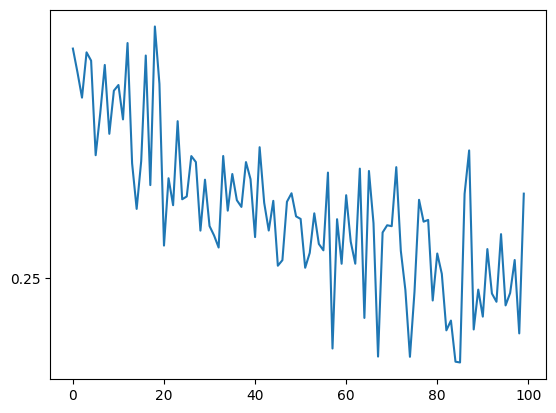

In [334]:
hidden_size = 128
batch_size = 128

input_lang, output_lang, train_dataloader = get_dataloader(batch_size)

encoder = EncoderRNN(embedding_dim, hidden_size).to(device)
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words).to(device)

encoder.load_state_dict(torch.load("encoder_sd.pt"))
decoder.load_state_dict(torch.load("decoder_sd.pt"))

train(train_dataloader, encoder, decoder, 2000, learning_rate=0.0000001, print_every=200, plot_every=20)

In [335]:
torch.save(encoder.state_dict(), 'encoder_sd.pt')
torch.save(decoder.state_dict(), 'decoder_sd.pt')
encoder.eval()
decoder.eval()
evaluateRandomly(encoder, decoder)

> ['So', 'in', 'Poppenbüttel', 'und', 'rund', 'um', 'die', 'Alster', '.']
= ['alpha', 'bereich', 'list', 'kreis', 'alster', 'alpha', 'alster', 'kreis']
< list list kreis list list kreis oral verschieden prod <EOS>

> ['Man', 'musste', '/']
= ['muss']
< off off ich off <EOS>

> ['Sie', 'ist', 'jetzt', '69', 'Jahre', 'alt', '.']
= ['index', 'ich', 'jetzt', 'einer9', 'zehner6', 'alt', 'off']
< ablauf ich einer9 zehner6 <EOS>

> ['Ich', 'habe', 'im', 'Kreis', 'Marienburg', 'gewohnt', '.']
= ['gest', 'kreis', 'pickel', 'burg', 'bereich', 'heimat', 'gehören']
< ich gewesen hörend wo kultur <EOS>

> ['Wie', 'hieß', 'die', 'denn', '?']
= ['wer', 'name']
< wie frage vergleich index index index <EOS>

> ['Mit', 'den', 'Freundschaften', 'klappt', 'auch', 'alles', 'wunderbar', '.']
= ['heiraten', 'alle', 'gut', 'alle', 'klappt']
< unterrichten zahl handlung super <EOS>

> ['Zu', 'Anfang', 'baut', 'man', 'eine', 'Basis', 'auf', '.']
= ['glauben', 'index', 'anfang', 'basis']
< index ablauf off weite

input = ja.
output = index treppe prod <EOS>


C:\Users\ivono\AppData\Local\Temp\ipykernel_9220\3602350326.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
C:\Users\ivono\AppData\Local\Temp\ipykernel_9220\3602350326.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


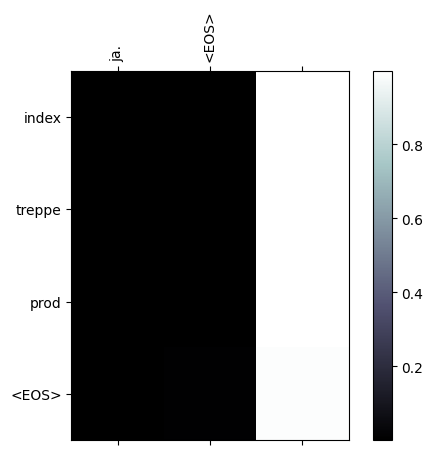

input = das netzwerk funktioniert noch nicht fehlerfrei
output = einer9 hunderter2 meter <EOS>


C:\Users\ivono\AppData\Local\Temp\ipykernel_9220\3602350326.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
C:\Users\ivono\AppData\Local\Temp\ipykernel_9220\3602350326.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


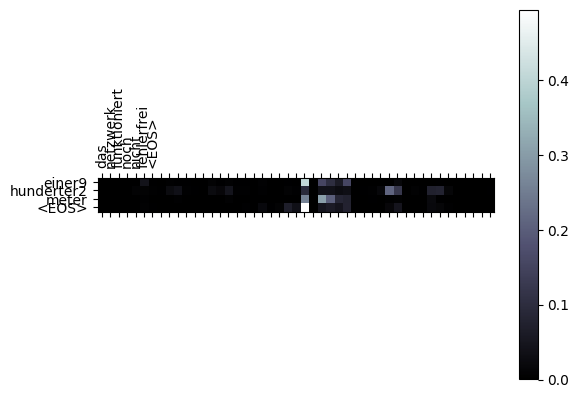

input = der attention mechanismus soll die performance verbessern
output = alpha alpha <EOS>


C:\Users\ivono\AppData\Local\Temp\ipykernel_9220\3602350326.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
C:\Users\ivono\AppData\Local\Temp\ipykernel_9220\3602350326.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


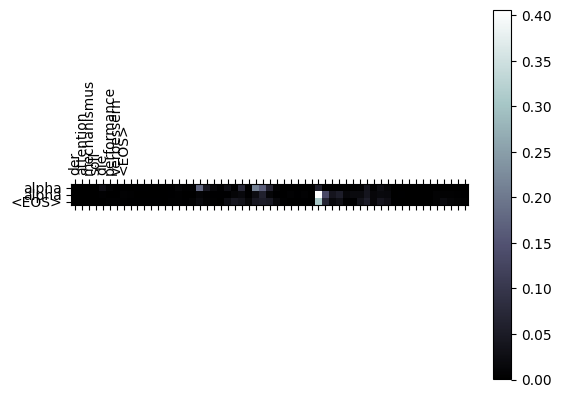

input = das hier ist ein weiterer beispielsatz
output = prod list drehen <EOS>


C:\Users\ivono\AppData\Local\Temp\ipykernel_9220\3602350326.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_sentence.split(' ') +
C:\Users\ivono\AppData\Local\Temp\ipykernel_9220\3602350326.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + output_words)


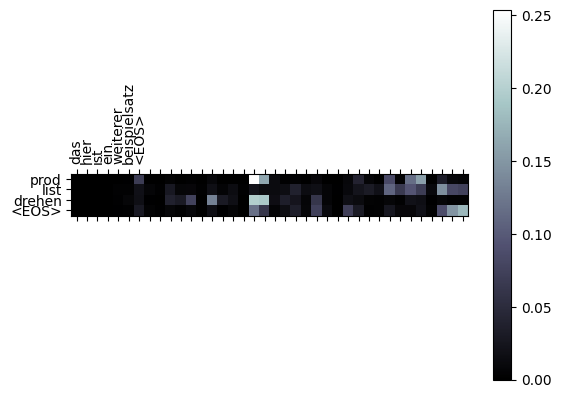

In [336]:
def showAttention(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap='bone')
    fig.colorbar(cax)

    # Set up axes
    ax.set_xticklabels([''] + input_sentence.split(' ') +
                       ['<EOS>'], rotation=90)
    ax.set_yticklabels([''] + output_words)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()


def evaluateAndShowAttention(input_sentence):
    output_words, attentions = evaluate(encoder, decoder, input_sentence, input_lang, output_lang)
    print('input =', input_sentence)
    print('output =', ' '.join(output_words))
    showAttention(input_sentence, output_words, attentions[0, :len(output_words), :])


evaluateAndShowAttention('ja.')

evaluateAndShowAttention('das netzwerk funktioniert noch nicht fehlerfrei')

evaluateAndShowAttention('der attention mechanismus soll die performance verbessern')

evaluateAndShowAttention('das hier ist ein weiterer beispielsatz')

In [337]:
from datetime import datetime
print(datetime.now().strftime("%H:%M:%S"))

19:21:54
